In [1]:
# ========== IMPORTS ==========
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.metrics import confusion_matrix

nltk.download("stopwords")

# ========== LOAD DATA ==========
true = pd.read_csv("../data/True.csv")
fake = pd.read_csv("../data/Fake.csv")

true["label"] = 1
fake["label"] = 0

df = pd.concat([true, fake]).sample(frac=1).reset_index(drop=True)

print("DATA SHAPE:", df.shape)
df.head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


DATA SHAPE: (44898, 5)


,title,text,subject,date,label
0,Macron determined to engage Germany in debate ...,FRANKFURT (Reuters) - French President Emmanue...,worldnews,"October 10, 2017",1
1,Fed Up Republicans Threaten Third Party Optio...,I ve been saying for a long time now that the ...,News,"March 3, 2016",0
2,Boris Johnson gives PM May advice on Brexit wh...,"MANCHESTER, England (Reuters) - British Foreig...",worldnews,"October 3, 2017",1
3,"Trump not aware of 2016 meeting between son, R...",WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,"July 9, 2017",1
4,BATTLE OF THE “PAUL’S”: Angry Rand Paul Walks ...,Senator Rand Paul (R-KY) made a big statement ...,Government News,"Feb 16, 2017",0


In [2]:
# ========== CLEANING ==========
stop_words = set(stopwords.words("english"))
ps = PorterStemmer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z]", " ", text)
    words = text.split()
    words = [ps.stem(w) for w in words if w not in stop_words]
    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

# Load model & vectorizer
model = pickle.load(open("../model.pkl", "rb"))
vectorizer = pickle.load(open("../vectorizer.pkl", "rb"))

X = vectorizer.transform(df["clean_text"])
y = df["label"]
y_pred = model.predict(X)

print("PREDICTIONS DONE")


PREDICTIONS DONE


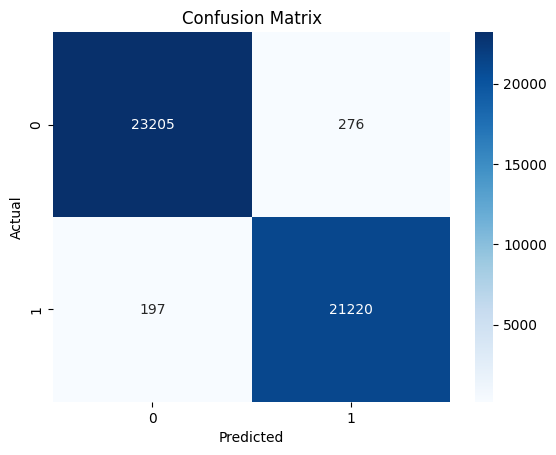

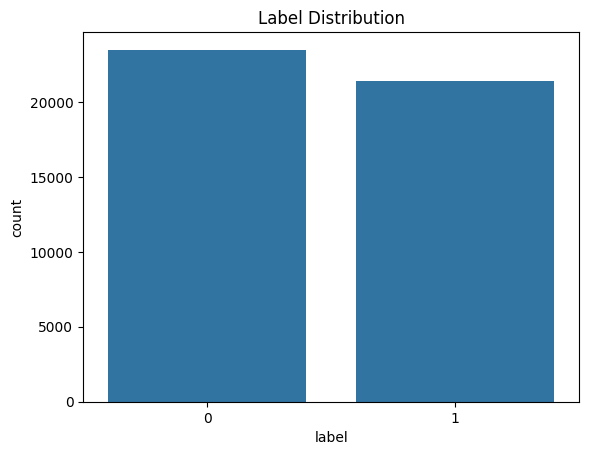

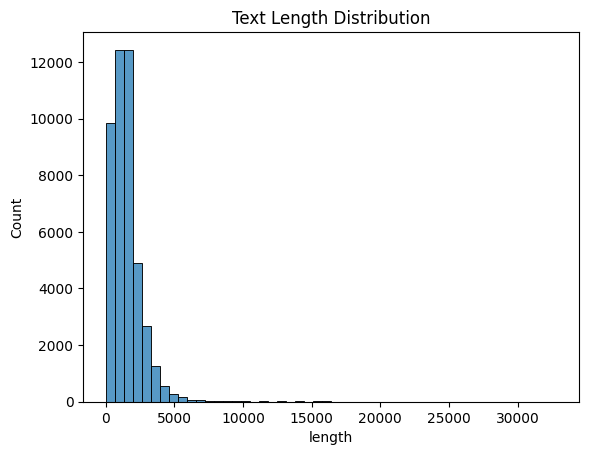

In [3]:
# ========== CONFUSION MATRIX ==========
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ========== LABEL DISTRIBUTION ==========
sns.countplot(x=y)
plt.title("Label Distribution")
plt.show()

# ========== TEXT LENGTH DISTRIBUTION ==========
df["length"] = df["clean_text"].apply(len)
sns.histplot(df["length"], bins=50)
plt.title("Text Length Distribution")
plt.show()
